# Data ingest and transformation

# FIX

## - Cap modified column titles
## - scaling by scenario probabilities
## - charts

In [2]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [3]:
# Load the provided JSON file
file_path = 'DE_L_results_T_10_delta_5_scen_21_trial_1_inv_2_cap._1_cap.inc._5.json'
with open(file_path, 'r') as file:
    data = json.load(file)
    
# Create the combined data dictionary according to the provided mapping
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

unique_producers = set(combined_data['Y_manufacturers_producing_period'].keys())
unique_vaccines = set(combined_data['Q_commitment_amounts'].keys())

# unique_producers, unique_vaccines

In [22]:
# Adjusting the ordering function to handle nested dictionaries with non-numeric keys
def order_data(data_dict):
    ordered_data = {}
    for key, value in data_dict.items():
        if isinstance(value, dict):
            ordered_data[key] = {k: order_data(v) if isinstance(v, dict) else v for k, v in sorted(value.items(), key=lambda item: int(item[0]) if item[0].isdigit() else item[0])}
        else:
            ordered_data[key] = value
    return ordered_data

# Apply ordering to combined_data
L_ordered = order_data(combined_data['L_capacity_extension_decision'])

# Convert the 'L_capacity_extension_decision' data into a DataFrame for better visualization
L_df = pd.DataFrame(L_ordered).sort_index()
# Rotate the DataFrame
L_df_rotated = L_df.transpose()
# Order the columns from 1 to 10
ordered_columns = [str(i) for i in range(1, 11)]
L_df_rotated_ordered = L_df_rotated[ordered_columns]
# Reset the index to make manufacturers the first column
L_df_rotated_ordered.reset_index(inplace=True)
L_df_rotated_ordered.rename(columns={'index': 'Manufacturer'}, inplace=True)

L_df_rotated_ordered = L_df_rotated_ordered.sort_values(by='Manufacturer').reset_index(drop=True)
L_df_rotated_ordered


C:\Users\nicho\AppData\Local\Temp\ipykernel_9584\3033444985.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  L_df_rotated_ordered.rename(columns={'index': 'Manufacturer'}, inplace=True)


,Manufacturer,1,2,3,4,5,6,7,8,9,10
0,AJ_Vaccines,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,BB_NCIPD,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2,Bharat_Biotech,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,Bilthoven,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,Biological_E,5.0,5.0,5.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
5,China_National,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
6,GSK,5.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
7,Haffkine_Bio,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
8,LG_Chem,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
9,Merck_Sharp,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [23]:
def transform_row(row):
    row = row.copy()
    if row.iloc[1] == 5.0:
        row.iloc[1] = 1.5
    else:
        row.iloc[1] = 1.0

    for i in range(2, len(row)):
        if row.iloc[i] == 5.0:
            row.iloc[i] = row.iloc[i-1] + 0.5
        else:
            row.iloc[i] = row.iloc[i-1]
    
    return row

# Apply the transformation to each row
transformed_capacity_increase = L_df_rotated_ordered.apply(transform_row, axis=1)
# Rename all columns except the first one to integers
transformed_capacity_increase.rename(columns={col: int(col) for col in transformed_capacity_increase.columns[1:]}, inplace=True)
transformed_capacity_increase.set_index(transformed_capacity_increase.columns[0], inplace=False)

,1,2,3,4,5,6,7,8,9,10
Manufacturer,,,,,,,,,,
AJ_Vaccines,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BB_NCIPD,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Bharat_Biotech,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Bilthoven,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Biological_E,1.5,2.0,2.5,2.5,2.5,2.5,2.5,2.5,2.5,2.5
China_National,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
GSK,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5,1.5
Haffkine_Bio,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
LG_Chem,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [24]:
# Load the uploaded Excel file
file_path = '../../data/production_capacity_scenarios/production_capacity_scenarios.xlsx'
xls = pd.ExcelFile(file_path)

# Read the "master capacity" sheet
df_master_capacity = pd.read_excel(xls, sheet_name='master_capacity')
# df_master_capacity = df_master_capacity.sort_values(by='Manufacturer')
df_master_capacity.set_index(df_master_capacity.columns[0], inplace=False)

df_master_capacity

,Manufacturer,1,2,3,4,5,6,7,8,9,10
0,AJ_Vaccines,7711003,7711003,7711003,7711003,7711003,7711003,7711003,7711003,7711003,7711003
1,BB_NCIPD,39223956,39223956,39223956,39223956,39223956,39223956,39223956,39223956,39223956,39223956
2,Bharat_Biotech,61029105,61029105,61029105,61029105,61029105,61029105,61029105,61029105,61029105,61029105
3,Bilthoven,12048153,12048153,12048153,12048153,12048153,12048153,12048153,12048153,12048153,12048153
4,Biological_E,164885690,164885690,164885690,164885690,164885690,164885690,164885690,164885690,164885690,164885690
5,China_National,12812242,12812242,12812242,12812242,12812242,12812242,12812242,12812242,12812242,12812242
6,GSK,226762686,226762686,226762686,226762686,226762686,226762686,226762686,226762686,226762686,226762686
7,Haffkine_Bio,80972855,80972855,80972855,80972855,80972855,80972855,80972855,80972855,80972855,80972855
8,LG_Chem,43702188,43702188,43702188,43702188,43702188,43702188,43702188,43702188,43702188,43702188
9,Merck_Sharp,56991052,56991052,56991052,56991052,56991052,56991052,56991052,56991052,56991052,56991052


In [45]:

# Performing the multiplication
adjusted_capacity = df_master_capacity.iloc[:, 1:11] * (transformed_capacity_increase.iloc[:, 1:11]/1)

# Adding the Manufacturer column back to the selected dataframe
adjusted_capacity['Manufacturer'] = df_master_capacity['Manufacturer']

adjusted_capacity = adjusted_capacity[[adjusted_capacity.columns[-1]] + list(adjusted_capacity.columns[:-1])]

adjusted_capacity.set_index(adjusted_capacity.columns[0], inplace=False)
adjusted_capacity

,Manufacturer,1,2,3,4,5,6,7,8,9,10
0,AJ_Vaccines,7711003.0,7.711003e+06,7.711003e+06,7.711003e+06,7.711003e+06,7.711003e+06,7.711003e+06,7.711003e+06,7.711003e+06,7.711003e+06
1,BB_NCIPD,39223956.0,3.922396e+07,3.922396e+07,3.922396e+07,3.922396e+07,3.922396e+07,3.922396e+07,3.922396e+07,3.922396e+07,3.922396e+07
2,Bharat_Biotech,61029105.0,6.102910e+07,6.102910e+07,6.102910e+07,6.102910e+07,6.102910e+07,6.102910e+07,6.102910e+07,6.102910e+07,6.102910e+07
3,Bilthoven,12048153.0,1.204815e+07,1.204815e+07,1.204815e+07,1.204815e+07,1.204815e+07,1.204815e+07,1.204815e+07,1.204815e+07,1.204815e+07
4,Biological_E,247328535.0,3.297714e+08,4.122142e+08,4.122142e+08,4.122142e+08,4.122142e+08,4.122142e+08,4.122142e+08,4.122142e+08,4.122142e+08
5,China_National,12812242.0,1.281224e+07,1.281224e+07,1.281224e+07,1.281224e+07,1.281224e+07,1.281224e+07,1.281224e+07,1.281224e+07,1.281224e+07
6,GSK,340144029.0,3.401440e+08,3.401440e+08,3.401440e+08,3.401440e+08,3.401440e+08,3.401440e+08,3.401440e+08,3.401440e+08,3.401440e+08
7,Haffkine_Bio,80972855.0,8.097286e+07,8.097286e+07,8.097286e+07,8.097286e+07,8.097286e+07,8.097286e+07,8.097286e+07,8.097286e+07,8.097286e+07
8,LG_Chem,43702188.0,4.370219e+07,4.370219e+07,4.370219e+07,4.370219e+07,4.370219e+07,4.370219e+07,4.370219e+07,4.370219e+07,4.370219e+07
9,Merck_Sharp,56991052.0,5.699105e+07,5.699105e+07,5.699105e+07,5.699105e+07,5.699105e+07,5.699105e+07,5.699105e+07,5.699105e+07,5.699105e+07


## Transform cap increase and capacity to one DF

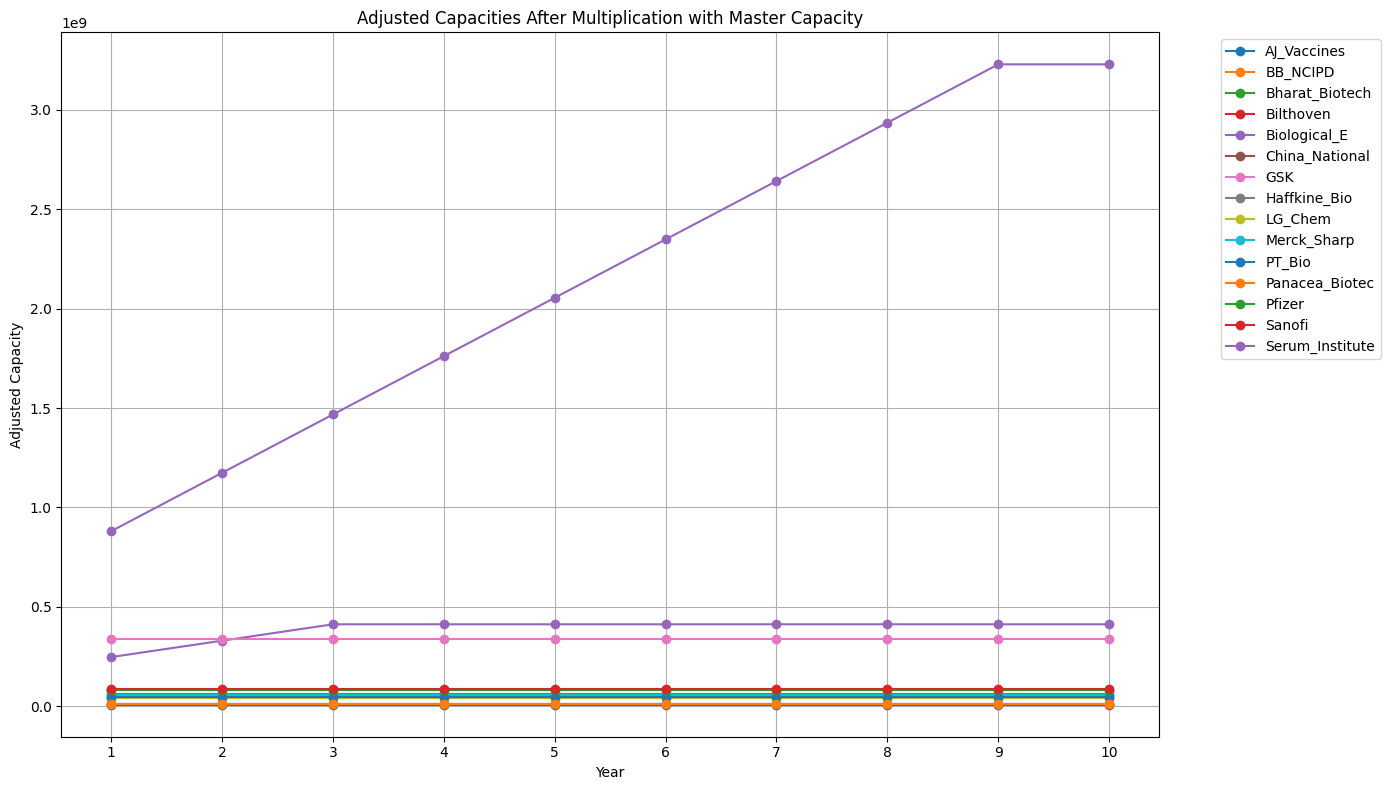

In [46]:
# Plotting the adjusted capacities after multiplication with master capacity as a line chart
fig, ax = plt.subplots(figsize=(14, 8))

for manufacturer in adjusted_capacity['Manufacturer']:
    y_values = adjusted_capacity[adjusted_capacity['Manufacturer'] == manufacturer].iloc[0, 1:]
    ax.plot(range(1, 11), y_values, label=manufacturer, marker='o')

ax.set_title('Adjusted Capacities After Multiplication with Master Capacity')
ax.set_xlabel('Year')
ax.set_ylabel('Adjusted Capacity')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()

plt.show()


# Graphing

In [ ]:

# Vaccines to filter
vaccines_to_filter = ["DTwP", "DTwP-Hib", "Penta"]

# Initialize dictionaries to store commitment and production amounts by vaccine
commitment_results = {}
production_results = {}

# Filter data to only look at Serum_Institute for the specified vaccines in commitments
for vaccine, producers in combined_data["Q_commitment_amounts"].items():
    if vaccine in vaccines_to_filter and "Serum_Institute" in producers:
        for time_period, commitments in producers["Serum_Institute"].items():
            if time_period not in commitment_results:
                commitment_results[time_period] = {}
            if vaccine not in commitment_results[time_period]:
                commitment_results[time_period][vaccine] = 0
            # Sum up the commitment amounts for the current time period and vaccine
            commitment_results[time_period][vaccine] += sum(commitments.values())

# Filter data to only look at Serum_Institute for the specified vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if vaccine in vaccines_to_filter and "Serum_Institute" in producers:
        for time_period, production in producers["Serum_Institute"].items():
            if time_period not in production_results:
                production_results[time_period] = {}
            if vaccine not in production_results[time_period]:
                production_results[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                production_results[time_period][vaccine] += sum(production.values())
            else:
                production_results[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(set(commitment_results.keys()).union(production_results.keys()), key=int)
vaccines = sorted(vaccines_to_filter)

commitment_data = {vaccine: [commitment_results.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}
production_data = {vaccine: [production_results.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_commitment = pd.DataFrame(commitment_data, index=time_periods)
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.35
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for commitments
bottom_commitment = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index, df_commitment[vaccine], bar_width, label=f'{vaccine} Commitment', bottom=bottom_commitment)
    bottom_commitment += df_commitment[vaccine]

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index + bar_width, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

ax.set_xlabel('Time Period')
ax.set_ylabel('Amount')
ax.set_title('Commitment vs Production for Serum_Institute over Time by Vaccine')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Provided combined data dictionary
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

# Vaccines to filter
vaccines_to_filter = ["DTwP", "DTwP-Hib", "Penta", "Hexa", "HepB", "Hib"]

# Initialize dictionary to store production amounts by vaccine and time period for Serum_Institute
serum_institute_production = {}

# Collect data for Serum_Institute and the specified vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if vaccine in vaccines_to_filter and "Serum_Institute" in producers:
        for time_period, production in producers["Serum_Institute"].items():
            if time_period not in serum_institute_production:
                serum_institute_production[time_period] = {}
            if vaccine not in serum_institute_production[time_period]:
                serum_institute_production[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                serum_institute_production[time_period][vaccine] += sum(production.values())
            else:
                serum_institute_production[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(serum_institute_production.keys(), key=int)
vaccines = sorted(vaccines_to_filter)

production_data = {vaccine: [serum_institute_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.5
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Serum Institute Production Over Time by Vaccine')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize dictionary to store production amounts by producer and time period for Penta vaccine
penta_production = {}

# Collect data for all producers for Penta vaccine in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if vaccine == "Penta":
        for producer, time_periods in producers.items():
            for time_period, production in time_periods.items():
                if producer not in penta_production:
                    penta_production[producer] = {}
                if time_period not in penta_production[producer]:
                    penta_production[producer][time_period] = 0
                # Sum the values if production is a nested dictionary
                if isinstance(production, dict):
                    penta_production[producer][time_period] += sum(production.values())
                else:
                    penta_production[producer][time_period] += production

# Prepare data for visualization
time_periods = sorted(set(tp for producer_data in penta_production.values() for tp in producer_data), key=int)
producers = sorted(penta_production.keys())

production_data = {producer: [penta_production.get(producer, {}).get(tp, 0) for tp in time_periods] for producer in producers}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.7
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for producer in producers:
    ax.bar(index, df_production[producer], bar_width, label=f'{producer} Production', bottom=bottom_production)
    bottom_production += df_production[producer]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Penta Vaccine Production Amounts Over Time by Producer')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Provided combined data dictionary
combined_data = {
    "F_tender_schedule": data.get("F", {}),
    "Y_manufacturers_producing_period": data.get("Y", {}),
    "W_manufacturers_participate_tender": data.get("W", {}),
    "L_capacity_extension_decision": data.get("L", {}),
    "Q_commitment_amounts": data.get("Q", {}),
    "X_production_amounts": data.get("X", {}),
    "I_inventory_level": data.get("I", {}),
    "Vc_vaccinated_children": data.get("Vc", {}),
    "S_unvaccinated_children": data.get("S", {})
}

# Initialize a dictionary to store production amounts by producer and year
production_results = {}

# Collect data for all producers and vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    for producer, time_periods in producers.items():
        for time_period, production in time_periods.items():
            if producer not in production_results:
                production_results[producer] = {}
            if time_period not in production_results[producer]:
                production_results[producer][time_period] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                production_results[producer][time_period] += sum(production.values())
            else:
                production_results[producer][time_period] += production

# Prepare data for visualization
time_periods = sorted(set(tp for producer_data in production_results.values() for tp in producer_data), key=int)
producers = sorted(production_results.keys())

production_data = {producer: [production_results.get(producer, {}).get(tp, 0) for tp in time_periods] for producer in producers}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.7
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for producer in producers:
    ax.bar(index, df_production[producer], bar_width, label=f'{producer} Production', bottom=bottom_production)
    bottom_production += df_production[producer]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Producer Performance Over Time')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize dictionary to store production amounts by vaccine and time period for Biological_E
biological_e_production = {}

# Collect data for Biological_E for all vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if "Biological_E" in producers:
        for time_period, production in producers["Biological_E"].items():
            if time_period not in biological_e_production:
                biological_e_production[time_period] = {}
            if vaccine not in biological_e_production[time_period]:
                biological_e_production[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                biological_e_production[time_period][vaccine] += sum(production.values())
            else:
                biological_e_production[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(biological_e_production.keys(), key=int)
vaccines = sorted(set(vaccine for tp_data in biological_e_production.values() for vaccine in tp_data))

production_data = {vaccine: [biological_e_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Plotting the data
bar_width = 0.5
index = np.arange(len(time_periods))

fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

ax.set_xlabel('Time Period')
ax.set_ylabel('Production Amount')
ax.set_title('Biological_E Production Over Time by Vaccine')
ax.set_xticks(index)
ax.set_xticklabels(time_periods)
ax.legend()

plt.grid(True)
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize dictionary to store production amounts by vaccine and time period for Biological_E
biological_e_production = {}

# Collect data for Biological_E for all vaccines in productions
for vaccine, producers in combined_data["X_production_amounts"].items():
    if "Biological_E" in producers:
        for time_period, production in producers["Biological_E"].items():
            if time_period not in biological_e_production:
                biological_e_production[time_period] = {}
            if vaccine not in biological_e_production[time_period]:
                biological_e_production[time_period][vaccine] = 0
            # Sum the values if production is a nested dictionary
            if isinstance(production, dict):
                biological_e_production[time_period][vaccine] += sum(production.values())
            else:
                biological_e_production[time_period][vaccine] += production

# Prepare data for visualization
time_periods = sorted(biological_e_production.keys(), key=int)
vaccines = sorted(set(vaccine for tp_data in biological_e_production.values() for vaccine in tp_data))

production_data = {vaccine: [biological_e_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

# Convert to DataFrame for easier manipulation
df_production = pd.DataFrame(production_data, index=time_periods)

# Collect capacity extension decisions for Biological_E
capacity_extension = combined_data["L_capacity_extension_decision"].get("Biological_E", {})
capacity_extension_data = [capacity_extension.get(tp, 0) for tp in time_periods]

# Plotting the data
bar_width = 0.5
index = np.arange(len(time_periods))

fig, ax1 = plt.subplots(figsize=(14, 8))

# Stacked bar for productions
bottom_production = np.zeros(len(time_periods))
for vaccine in vaccines:
    ax1.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
    bottom_production += df_production[vaccine]

# Adding upward facing arrows for capacity extension
for i, (tp, capacity) in enumerate(zip(time_periods, capacity_extension_data)):
    if capacity > 0:
        ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')

# Adding labels and titles
ax1.set_xlabel('Time Period')
ax1.set_ylabel('Production Amount')
ax1.set_title('Biological_E Production and Capacity Extension Over Time by Vaccine')
ax1.set_xticks(index)
ax1.set_xticklabels(time_periods)

# Adding legend
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc='upper left')

plt.grid(True)
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_production_with_capacity_extension(producer, combined_data):
    # Initialize dictionary to store production amounts by vaccine and time period for the specified producer
    producer_production = {}

    # Collect data for the specified producer for all vaccines in productions
    for vaccine, producers in combined_data["X_production_amounts"].items():
        if producer in producers:
            for time_period, production in producers[producer].items():
                if time_period not in producer_production:
                    producer_production[time_period] = {}
                if vaccine not in producer_production[time_period]:
                    producer_production[time_period][vaccine] = 0
                # Sum the values if production is a nested dictionary
                if isinstance(production, dict):
                    producer_production[time_period][vaccine] += sum(production.values())
                else:
                    producer_production[time_period][vaccine] += production

    # Prepare data for visualization
    time_periods = sorted(producer_production.keys(), key=int)
    vaccines = sorted(set(vaccine for tp_data in producer_production.values() for vaccine in tp_data))

    production_data = {vaccine: [producer_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

    # Convert to DataFrame for easier manipulation
    df_production = pd.DataFrame(production_data, index=time_periods)

    # Collect capacity extension decisions for the specified producer
    capacity_extension = combined_data["L_capacity_extension_decision"].get(producer, {})
    capacity_extension_data = [capacity_extension.get(tp, 0) for tp in time_periods]

    # Plotting the data
    bar_width = 0.5
    index = np.arange(len(time_periods))

    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Stacked bar for productions
    bottom_production = np.zeros(len(time_periods))
    for vaccine in vaccines:
        ax1.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production)
        bottom_production += df_production[vaccine]

    # Adding upward facing arrows for capacity extension
    for i, (tp, capacity) in enumerate(zip(time_periods, capacity_extension_data)):
        if capacity > 0:
            ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')

    # Adding labels and titles
    ax1.set_xlabel('Time Period')
    ax1.set_ylabel('Production Amount')
    ax1.set_title(f'{producer} Production and Capacity Extension Over Time by Vaccine')
    ax1.set_xticks(index)
    ax1.set_xticklabels(time_periods)

    # Adding legend
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc='upper left')

    plt.grid(True)
    plt.show()

# Example usage
plot_production_with_capacity_extension("Serum_Institute", combined_data)


In [ ]:
import matplotlib.pyplot as plt

def plot_capacity_over_time(capacity_data, producers):
    """
    Plots the capacity over time for the given list of producers.

    Parameters:
    capacity_data (pd.DataFrame): DataFrame containing the capacity data with 'Manufacturer' column.
    producers (list): List of producers to plot.

    Returns:
    None
    """
    # Filter the capacity data for the specified producers
    filtered_data = capacity_data[capacity_data['Manufacturer'].isin(producers)]
    
    # Set the 'Manufacturer' as the index for easy plotting
    filtered_data.set_index('Manufacturer', inplace=True)
    
    # Plot each producer's capacity over time
    for producer in producers:
        if producer in filtered_data.index:
            plt.figure(figsize=(10, 6))
            plt.plot(filtered_data.columns, filtered_data.loc[producer], marker='o', linestyle='-')
            plt.title(f'Capacity Over Time for {producer}')
            plt.xlabel('Time Period')
            plt.ylabel('Capacity')
            plt.grid(True)
            plt.show()

# Example usage of the function
example_producers = ['Serum_Institute']
plot_capacity_over_time(adjusted_capacity, example_producers)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Subset capacity data based on the producer list
# subset_capacity_data = final_df[final_df['Manufacturer'].isin(unique_producers_list)]

# Define the function to plot production with capacity extension
def plot_production_with_capacity_extension(producers, combined_data, vaccines_to_filter):
    # Define a color map for vaccines
    vaccine_colors = {
        "DT": "darkolivegreen",
        "DTwP": "green",
        "DTwP-Hib": "greenyellow",
        "Hexa": "red",
        "Penta": "orange",
        "HepB": "yellow",
        "IPV": "lemonchiffon",
        "Hib": "lightgoldenrodyellow",
        "HepB": "lime",
        "OPV": "bisque",
        "Penta": "antiquewhite",
        "Rota": "aqua",
        "TT": "coral",
        "HPV": "gold",
        'PCV': "tomato",
        'Td': "burlywood",
        'Measles': "blue",
        'MMR': "aliceblue",
        'MR': "cadetblue",
    }

    for producer in producers:
        # Initialize dictionary to store production amounts by vaccine and time period for the specified producer
        producer_production = {}
        producer_capacity = {}

        # Collect data for the specified producer for the specified vaccines in productions
        for vaccine, producers_data in combined_data["X_production_amounts"].items():
            if vaccine in vaccines_to_filter and producer in producers_data:
                for time_period, production in producers_data[producer].items():
                    if time_period not in producer_production:
                        producer_production[time_period] = {}
                    if vaccine not in producer_production[time_period]:
                        producer_production[time_period][vaccine] = 0
                    # Sum the values if production is a nested dictionary
                    if isinstance(production, dict):
                        producer_production[time_period][vaccine] += sum(production.values())
                    else:
                        producer_production[time_period][vaccine] += production

        # Prepare data for visualization
        time_periods = sorted(producer_production.keys(), key=int)
        vaccines = sorted(set(vaccine for tp_data in producer_production.values() for vaccine in tp_data))

        production_data = {vaccine: [producer_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

        # Convert to DataFrame for easier manipulation
        df_production = pd.DataFrame(production_data, index=time_periods)

        # Collect capacity extension decisions for the specified producer
        capacity_extension = combined_data["L_capacity_extension_decision"].get(producer, {})
        capacity_extension_data = [capacity_extension.get(tp, 0) for tp in time_periods]

        # Plotting the data
        bar_width = 0.5
        index = np.arange(len(time_periods))

        fig, ax1 = plt.subplots(figsize=(14, 8))

        # Stacked bar for productions
        bottom_production = np.zeros(len(time_periods))
        for vaccine in vaccines:
            color = vaccine_colors.get(vaccine, "gray")  # Default to gray if vaccine not in color map
            ax1.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production, color=color)
            bottom_production += df_production[vaccine]

        # Adding upward facing arrows for capacity extension
        for i, (tp, capacity) in enumerate(zip(time_periods, capacity_extension_data)):
            if capacity > 0:
                ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')

        # # Plotting the capacity data as a black line
        # ax2 = ax1.twinx()
        # ax2.plot(index, capacity_values, label='Capacity', color='black', marker='o')
        # ax2.set_ylabel('Capacity')

        # Adding labels and titles
        ax1.set_xlabel('Time Period')
        ax1.set_ylabel('Production Amount')
        ax1.set_title(f'{producer} Production and Capacity Extension Over Time by Vaccine')
        ax1.set_xticks(index)
        ax1.set_xticklabels(time_periods)

        # Adding legend
        handles1, labels1 = ax1.get_legend_handles_labels()
        # handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 , labels1 , loc='upper left')

        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Example call to the function with subsetted capacity data
plot_production_with_capacity_extension(unique_producers, combined_data, unique_vaccines)


Serum_Institute


C:\Users\nicho\AppData\Local\Temp\ipykernel_9584\255995511.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')


Producer: Serum_Institute, value: [8.80671144e+07 1.17422819e+08 1.46778524e+08 1.76134229e+08
 2.05489934e+08 2.34845638e+08 2.64201343e+08 2.93557048e+08
 3.22912753e+08 3.22912753e+08]


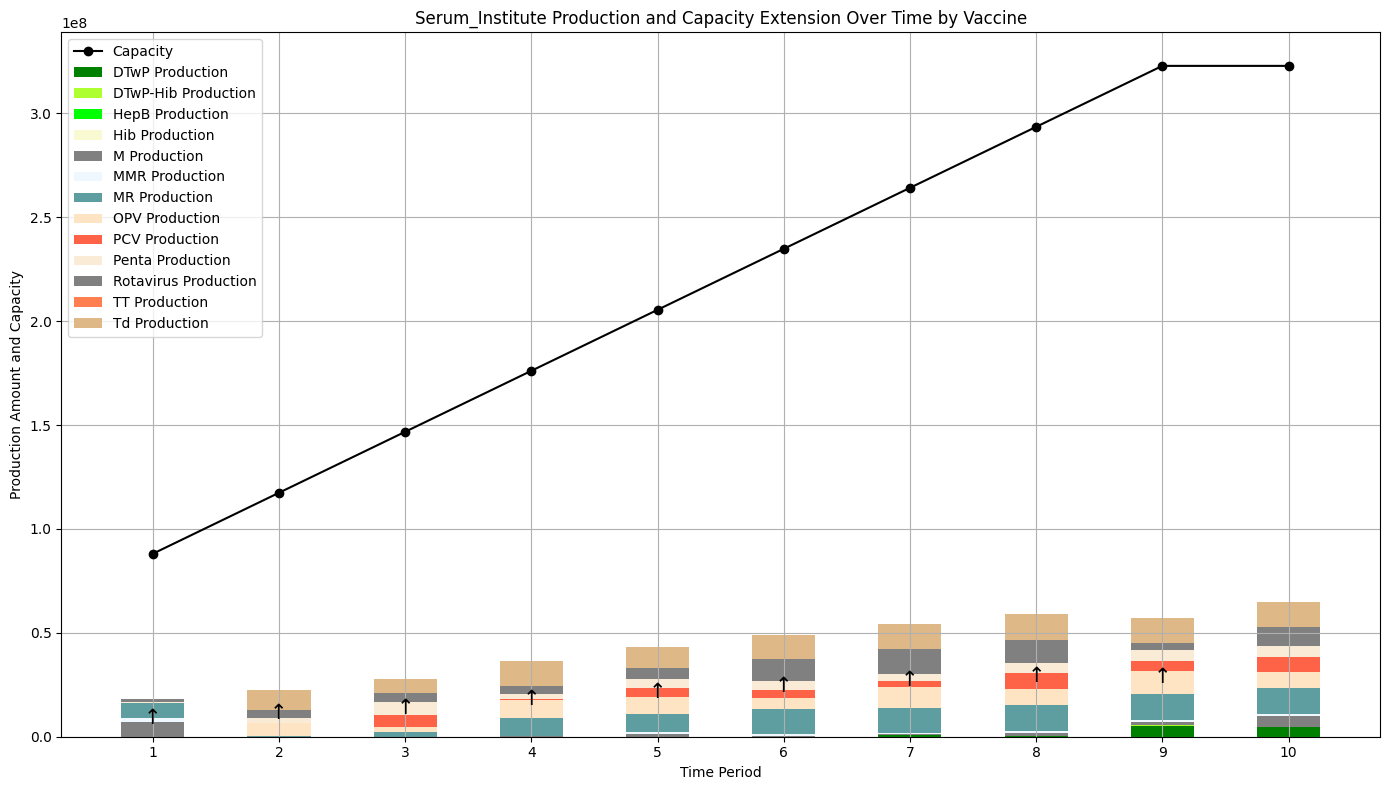

In [42]:
def plot_production_with_capacity_extension(producers, combined_data, vaccines_to_filter, capacity_data):
    # Define a color map for vaccines
    vaccine_colors = {
        "DT": "darkolivegreen",
        "DTwP": "green",
        "DTwP-Hib": "greenyellow",
        "Hexa": "red",
        "Penta": "orange",
        "HepB": "yellow",
        "IPV": "lemonchiffon",
        "Hib": "lightgoldenrodyellow",
        "HepB": "lime",
        "OPV": "bisque",
        "Penta": "antiquewhite",
        "Rota": "aqua",
        "TT": "coral",
        "HPV": "gold",
        'PCV': "tomato",
        'Td': "burlywood",
        'Measles': "blue",
        'MMR': "aliceblue",
        'MR': "cadetblue",
    }

    # Convert capacity_data columns to strings
    capacity_data.columns = capacity_data.columns.map(str)

    for producer in producers:
        print(producer)
        # Initialize dictionary to store production amounts by vaccine and time period for the specified producer
        producer_production = {}
        producer_capacity = {}

        # Collect data for the specified producer for the specified vaccines in productions
        for vaccine, producers_data in combined_data["X_production_amounts"].items():
            if vaccine in vaccines_to_filter and producer in producers_data:
                for time_period, production in producers_data[producer].items():
                    if time_period not in producer_production:
                        producer_production[time_period] = {}
                    if vaccine not in producer_production[time_period]:
                        producer_production[time_period][vaccine] = 0
                    # Sum the values if production is a nested dictionary
                    if isinstance(production, dict):
                        producer_production[time_period][vaccine] += sum(production.values())
                    else:
                        producer_production[time_period][vaccine] += production

        # Prepare data for visualization
        time_periods = sorted(producer_production.keys(), key=int)
        vaccines = sorted(set(vaccine for tp_data in producer_production.values() for vaccine in tp_data))

        production_data = {vaccine: [producer_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

        # Convert to DataFrame for easier manipulation
        df_production = pd.DataFrame(production_data, index=time_periods)

        # Collect capacity extension decisions for the specified producer
        capacity_extension = combined_data["L_capacity_extension_decision"].get(producer, {})
        capacity_extension_data = [capacity_extension.get(tp, 0) for tp in time_periods]

        # Plotting the data
        bar_width = 0.5
        index = np.arange(len(time_periods))

        fig, ax1 = plt.subplots(figsize=(14, 8))

        # Stacked bar for productions
        bottom_production = np.zeros(len(time_periods))
        for vaccine in vaccines:
            color = vaccine_colors.get(vaccine, "gray")  # Default to gray if vaccine not in color map
            ax1.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production, color=color)
            bottom_production += df_production[vaccine]

        # Adding upward facing arrows for capacity extension
        for i, (tp, capacity) in enumerate(zip(time_periods, capacity_extension_data)):
            if capacity > 0:
                ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')

        # Plotting the capacity data as a black line
        capacity_values = capacity_data.loc[capacity_data['Manufacturer'] == producer, time_periods].values.flatten()
        print(f"Producer: {producer}, value: {capacity_values}")
        ax1.plot(index, capacity_values, label='Capacity', color='black', marker='o')

        # Adding labels and titles
        ax1.set_xlabel('Time Period')
        ax1.set_ylabel('Production Amount and Capacity')
        ax1.set_title(f'{producer} Production and Capacity Extension Over Time by Vaccine')
        ax1.set_xticks(index)
        ax1.set_xticklabels(time_periods)

        # Adding legend
        handles1, labels1 = ax1.get_legend_handles_labels()
        ax1.legend(handles1, labels1, loc='upper left')

        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Example usage of the function
plot_production_with_capacity_extension(['Serum_Institute'], combined_data, unique_vaccines, adjusted_capacity)


In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_production_with_capacity_extension(producers, combined_data, vaccines_to_filter, capacity_data):
    # Define a color map for vaccines
    vaccine_colors = {
        "DT": "darkolivegreen",
        "DTwP": "green",
        "DTwP-Hib": "greenyellow",
        "Hexa": "red",
        "Penta": "orange",
        "HepB": "yellow",
        "IPV": "lemonchiffon",
        "Hib": "lightgoldenrodyellow",
        "HepB": "lime",
        "OPV": "bisque",
        "Penta": "antiquewhite",
        "Rota": "aqua",
        "TT": "coral",
        "HPV": "gold",
        'PCV': "tomato",
        'Td': "burlywood",
        'Measles': "blue",
        'MMR': "aliceblue",
        'MR': "cadetblue",
    }

    # Convert capacity_data columns to strings
    capacity_data.columns = capacity_data.columns.map(str)

    for producer in producers:
        print(producer)
        # Initialize dictionary to store production amounts by vaccine and time period for the specified producer
        producer_production = {}
        producer_capacity = {}

        # Collect data for the specified producer for the specified vaccines in productions
        for vaccine, producers_data in combined_data["X_production_amounts"].items():
            if vaccine in vaccines_to_filter and producer in producers_data:
                for time_period, production in producers_data[producer].items():
                    if time_period not in producer_production:
                        producer_production[time_period] = {}
                    if vaccine not in producer_production[time_period]:
                        producer_production[time_period][vaccine] = 0
                    # Sum the values if production is a nested dictionary
                    if isinstance(production, dict):
                        producer_production[time_period][vaccine] += sum(production.values())
                    else:
                        producer_production[time_period][vaccine] += production

        # Prepare data for visualization
        time_periods = sorted(producer_production.keys(), key=int)
        vaccines = sorted(set(vaccine for tp_data in producer_production.values() for vaccine in tp_data))

        production_data = {vaccine: [producer_production.get(tp, {}).get(vaccine, 0) for tp in time_periods] for vaccine in vaccines}

        # Convert to DataFrame for easier manipulation
        df_production = pd.DataFrame(production_data, index=time_periods)

        # Collect capacity extension decisions for the specified producer
        capacity_extension = combined_data["L_capacity_extension_decision"].get(producer, {})
        capacity_extension_data = [capacity_extension.get(tp, 0) for tp in time_periods]

        # Plotting the data
        bar_width = 0.5
        index = np.arange(len(time_periods))

        fig, ax1 = plt.subplots(figsize=(14, 8))

        # Stacked bar for productions
        bottom_production = np.zeros(len(time_periods))
        for vaccine in vaccines:
            color = vaccine_colors.get(vaccine, "gray")  # Default to gray if vaccine not in color map
            ax1.bar(index, df_production[vaccine], bar_width, label=f'{vaccine} Production', bottom=bottom_production, color=color)
            bottom_production += df_production[vaccine]

        # Adding upward facing arrows for capacity extension
        for i, (tp, capacity) in enumerate(zip(time_periods, capacity_extension_data)):
            if capacity > 0:
                ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')

        # Plotting the capacity data as a black line
        capacity_values = capacity_data.loc[capacity_data['Manufacturer'] == producer, time_periods].values.flatten()
        print(f"Producer: {producer}, value: {capacity_values}")
        ax1.plot(index, capacity_values, label='Capacity', color='black', marker='o')

        # Adding labels for each marker
        for i, value in enumerate(capacity_values):
            ax1.text(index[i], value, str(value), ha='center', va='bottom')

        # Adding labels and titles
        ax1.set_xlabel('Time Period')
        ax1.set_ylabel('Production Amount and Capacity')
        ax1.set_title(f'{producer} Production and Capacity Extension Over Time by Vaccine')
        ax1.set_xticks(index)
        ax1.set_xticklabels(time_periods)

        # Adding legend
        handles1, labels1 = ax1.get_legend_handles_labels()
        ax1.legend(handles1, labels1, loc='upper left')

        plt.grid(True)
        plt.tight_layout()
        plt.show()


Serum_Institute


C:\Users\nicho\AppData\Local\Temp\ipykernel_9584\212026589.py:81: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.annotate('↑', (index[i], bottom_production[i] / 2), ha='center', va='center', fontsize=15, color='black')


Producer: Serum_Institute, value: [8.80671144e+08 1.17422819e+09 1.46778524e+09 1.76134229e+09
 2.05489934e+09 2.34845638e+09 2.64201343e+09 2.93557048e+09
 3.22912753e+09 3.22912753e+09]


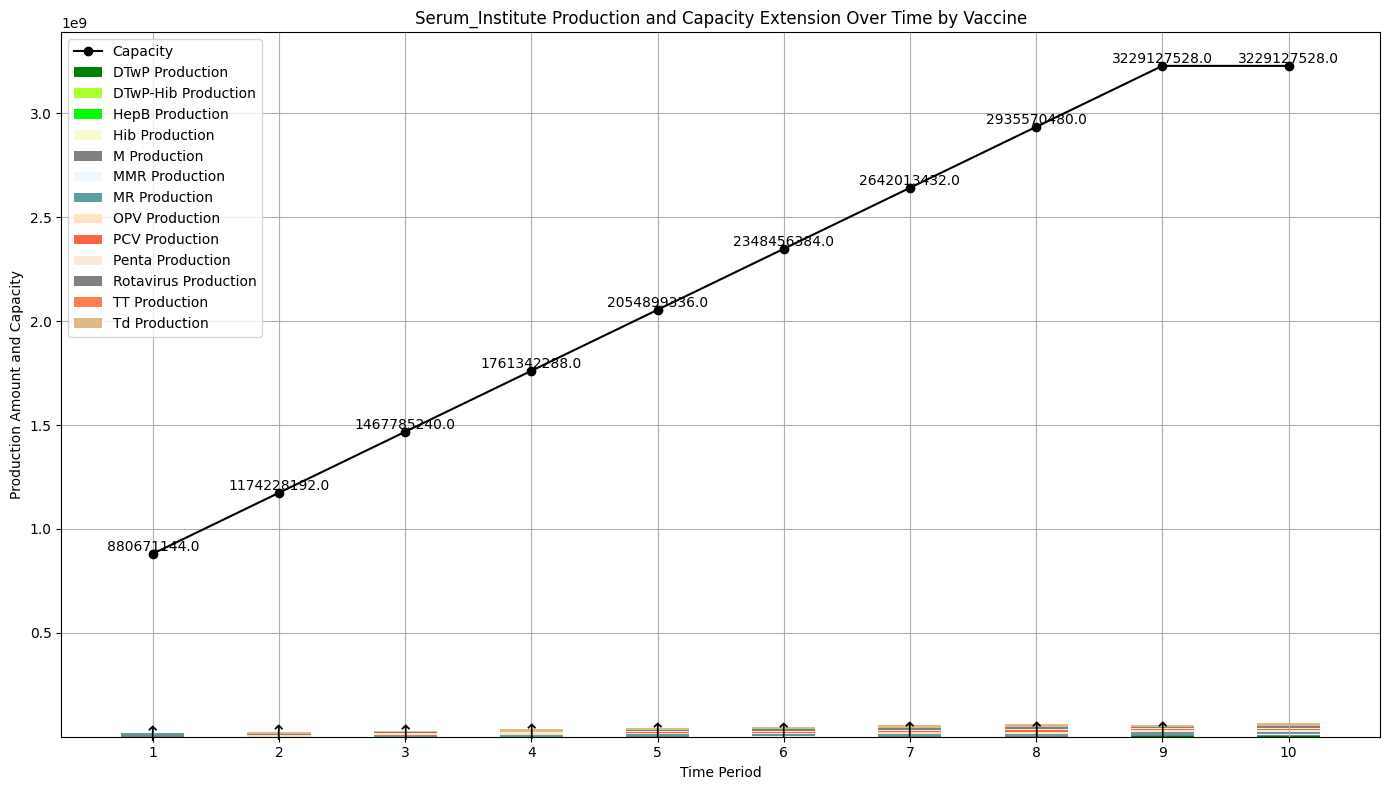

In [47]:
plot_production_with_capacity_extension(['Serum_Institute'], combined_data, unique_vaccines, adjusted_capacity)